In [2]:
from pathlib import Path

# Locate the project root.
current = Path.cwd().resolve()
ROOT = next(
    (p for p in [current, *current.parents]
     if (p / "data_raw").is_dir()
     and (p / "notebooks").is_dir()),
    None
)

if ROOT is None:
    raise FileNotFoundError("Project folder not found.")

SCENE_ID = "LC08_L2SP_195023_20260812_20260816_02_T1"
SCENE_DIR = ROOT / "data_raw" / "landsat" / SCENE_ID
DATA = ROOT / "data_processed"
OUTPUTS = ROOT / "outputs"

required = [
    "SR_B4.TIF",
    "SR_B5.TIF",
    "ST_B10.TIF",
    "QA_PIXEL.TIF",
    "QA_RADSAT.TIF",
    "SR_QA_AEROSOL.TIF",
    "ST_QA.TIF",
    "ST_CDIST.TIF",
    "MTL.txt",
]

files = {}
for suffix in required:
    path = SCENE_DIR / f"{SCENE_ID}_{suffix}"
    ready = path.is_file() and path.stat().st_size > 0
    print(f"{'OK' if ready else 'MISSING OR EMPTY'} — {suffix}")
    files[suffix] = path

OK — SR_B4.TIF
OK — SR_B5.TIF
OK — ST_B10.TIF
OK — QA_PIXEL.TIF
OK — QA_RADSAT.TIF
OK — SR_QA_AEROSOL.TIF
OK — ST_QA.TIF
OK — ST_CDIST.TIF
OK — MTL.txt


In [3]:
%pip install rasterio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import rasterio
import geopandas as gpd
from shapely.geometry import box

districts = gpd.read_file(
    DATA / "districts_access_summary.gpkg",
    layer="districts_access_summary"
)

reference_grid = None

for suffix, path in files.items():
    if not suffix.endswith(".TIF"):
        continue

    with rasterio.open(path) as src:
        grid = (src.crs, src.transform, src.width, src.height)

        if reference_grid is None:
            reference_grid = grid

        print(
            f"{suffix}: "
            f"CRS={src.crs}, "
            f"pixel={src.res}, "
            f"same grid={grid == reference_grid}"
        )

        if suffix == "SR_B4.TIF":
            projected = districts.to_crs(src.crs)
            footprint = box(*src.bounds)

            all_inside = projected.geometry.apply(
                footprint.covers
            ).all()

            print(
                "All district geometries inside raster bounds:",
                bool(all_inside)
            )

SR_B4.TIF: CRS=EPSG:32632, pixel=(30.0, 30.0), same grid=True
All district geometries inside raster bounds: False
SR_B5.TIF: CRS=EPSG:32632, pixel=(30.0, 30.0), same grid=True
ST_B10.TIF: CRS=EPSG:32632, pixel=(30.0, 30.0), same grid=True
QA_PIXEL.TIF: CRS=EPSG:32632, pixel=(30.0, 30.0), same grid=True
QA_RADSAT.TIF: CRS=EPSG:32632, pixel=(30.0, 30.0), same grid=True
SR_QA_AEROSOL.TIF: CRS=EPSG:32632, pixel=(30.0, 30.0), same grid=True
ST_QA.TIF: CRS=EPSG:32632, pixel=(30.0, 30.0), same grid=True
ST_CDIST.TIF: CRS=EPSG:32632, pixel=(30.0, 30.0), same grid=True


In [5]:
with rasterio.open(files["SR_B4.TIF"]) as src:
    projected = districts.to_crs(src.crs)
    raster_bounds = box(*src.bounds)

coverage = projected[["bezirk_name"]].copy()

coverage["total_km2"] = projected.geometry.area / 1_000_000
coverage["outside_bounds_km2"] = (
    projected.geometry.difference(raster_bounds).area / 1_000_000
)
coverage["outside_bounds_pct"] = (
    coverage["outside_bounds_km2"] / coverage["total_km2"] * 100
)

display(
    coverage.sort_values("outside_bounds_km2", ascending=False)
    .round(3)
    .reset_index(drop=True)
)

,bezirk_name,total_km2,outside_bounds_km2,outside_bounds_pct
0,Hamburg-Mitte,142.166,7.621,5.36
1,Altona,77.850,0.000,0.00
2,Eimsbüttel,49.771,0.000,0.00
3,Hamburg-Nord,57.727,0.000,0.00
4,Wandsbek,147.426,0.000,0.00
5,Bergedorf,154.617,0.000,0.00
6,Harburg,125.018,0.000,0.00


C:\Users\PC\AppData\Local\Temp\ipykernel_23000\1204384095.py:6: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  ~outside.geometry.is_empty & outside.geometry.notna()


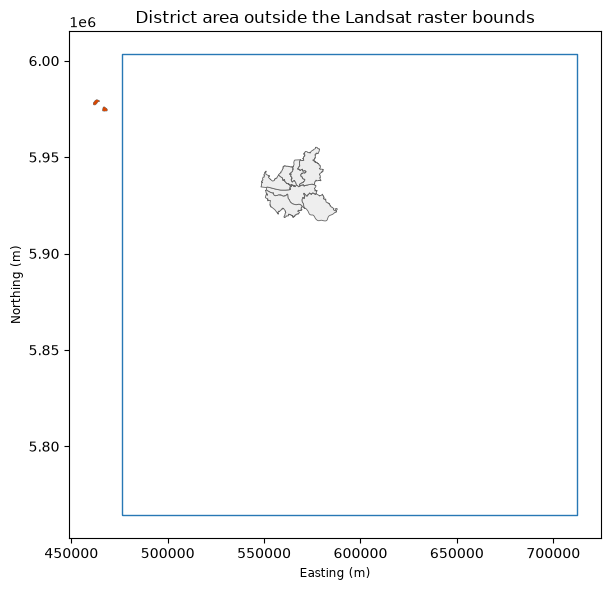

Hamburg-Mitte: longitude=8.4655, latitude=53.9382


In [6]:
import matplotlib.pyplot as plt

outside = projected.copy()
outside.geometry = projected.geometry.difference(raster_bounds)
outside = outside[
    ~outside.geometry.is_empty & outside.geometry.notna()
]

fig, ax = plt.subplots(figsize=(10, 6))

projected.plot(
    ax=ax, facecolor="#EEEEEE",
    edgecolor="#666666", linewidth=0.6
)
outside.plot(ax=ax, color="#D94701")

gpd.GeoSeries(
    [raster_bounds], crs=projected.crs
).boundary.plot(
    ax=ax, color="#2878B5", linewidth=1
)

ax.set_title("District area outside the Landsat raster bounds")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

for _, row in outside.iterrows():
    centre = gpd.GeoSeries(
        [row.geometry.centroid], crs=projected.crs
    ).to_crs(epsg=4326).iloc[0]

    print(
        f"{row['bezirk_name']}: "
        f"longitude={centre.x:.4f}, latitude={centre.y:.4f}"
    )

In [7]:
# Define the scene-covered study area.
# The excluded district area corresponds to the remote Neuwerk islands.
study_districts = projected.copy()
study_districts.geometry = (
    study_districts.geometry.intersection(raster_bounds)
)

study_districts = study_districts[
    study_districts.geometry.notna()
    & ~study_districts.geometry.is_empty
].copy()

excluded_km2 = (
    projected.geometry.area.sum()
    - study_districts.geometry.area.sum()
) / 1_000_000

print(f"Excluded area: {excluded_km2:.3f} km²")
print("Districts retained:", len(study_districts))

Excluded area: 7.621 km²
Districts retained: 7


In [8]:
import numpy as np
from rasterio.mask import mask
from rasterio.features import geometry_mask

shapes = [
    geom.__geo_interface__
    for geom in study_districts.geometry
]

with rasterio.open(files["QA_PIXEL.TIF"]) as src:
    qa_crop, crop_transform = mask(
        src, shapes, crop=True, filled=False
    )

qa = qa_crop.data[0]

# Identify pixels whose centres fall inside the study area.
inside = geometry_mask(
    shapes,
    out_shape=qa.shape,
    transform=crop_transform,
    invert=True
)

# Landsat 8–9 QA_PIXEL flags.
fill = (qa & (1 << 0)) != 0
cloud_shadow_snow = (qa & sum(1 << b for b in (1, 2, 3, 4, 5))) != 0
water = (qa & (1 << 7)) != 0

available = inside & ~fill & ~np.ma.getmaskarray(qa_crop)[0]
clear = available & ~cloud_shadow_snow
clear_land = clear & ~water

total = inside.sum()
if total == 0:
    raise ValueError("No pixels found inside the study area.")

print(f"Study-area pixels: {total:,}")
print(f"Available data: {100 * available.sum() / total:.2f}%")
print(
    "Cloud/shadow/snow flagged: "
    f"{100 * (available & cloud_shadow_snow).sum() / total:.2f}%"
)
print(f"Clear pixels including water: {100 * clear.sum() / total:.2f}%")
print(f"Clear land pixels: {100 * clear_land.sum() / total:.2f}%")

Study-area pixels: 829,952
Available data: 100.00%
Cloud/shadow/snow flagged: 0.45%
Clear pixels including water: 99.55%
Clear land pixels: 95.21%


In [9]:
# Read each band over the same study area.
def read_crop(suffix):
    with rasterio.open(files[suffix]) as src:
        cropped, transform = mask(
            src, shapes, crop=True, filled=False
        )
        if transform != crop_transform or cropped.shape[1:] != qa.shape:
            raise ValueError(f"Grid mismatch: {suffix}")
        return cropped[0].astype("float32").filled(np.nan)

red_dn = read_crop("SR_B4.TIF")
nir_dn = read_crop("SR_B5.TIF")
temp_dn = read_crop("ST_B10.TIF")
radsat = read_crop("QA_RADSAT.TIF")
aerosol_raw = read_crop("SR_QA_AEROSOL.TIF")

# Convert digital numbers to surface reflectance and temperature.
red = red_dn * 0.0000275 - 0.2
nir = nir_dn * 0.0000275 - 0.2
lst_celsius = temp_dn * 0.00341802 + 149.0 - 273.15

# Exclude saturated pixels and high-aerosol conditions.
aerosol = np.nan_to_num(aerosol_raw, nan=0).astype("uint16")
high_aerosol = ((aerosol >> 6) & 3) == 3

reflectance_ok = (
    clear_land
    & (radsat == 0)
    & np.isfinite(aerosol_raw)
    & ~high_aerosol
    & (red_dn > 0)
    & (nir_dn > 0)
    & (red >= 0) & (red <= 1)
    & (nir >= 0) & (nir <= 1)
    & ((nir + red) > 0)
)

ndvi = np.full(red.shape, np.nan, dtype="float32")
np.divide(
    nir - red,
    nir + red,
    out=ndvi,
    where=reflectance_ok
)

# Preliminary temperature mask; uncertainty checks follow.
temperature_ok = (
    clear_land
    & (radsat == 0)
    & (temp_dn > 0)
    & np.isfinite(lst_celsius)
)
lst_celsius[~temperature_ok] = np.nan

paired = np.isfinite(ndvi) & np.isfinite(lst_celsius)

if not paired.any():
    raise ValueError("No valid paired NDVI and temperature pixels.")

print(f"Paired pixels: {paired.sum():,}")
print(f"Paired coverage of study area: {100 * paired.sum() / inside.sum():.2f}%")

for name, values in [
    ("NDVI", ndvi[paired]),
    ("Surface temperature (°C)", lst_celsius[paired])
]:
    p = np.percentile(values, [2, 50, 98])
    print(f"{name}: P2={p[0]:.2f}, median={p[1]:.2f}, P98={p[2]:.2f}")

Paired pixels: 776,953
Paired coverage of study area: 93.61%
NDVI: P2=0.09, median=0.67, P98=0.89
Surface temperature (°C): P2=21.06, median=28.52, P98=36.08


In [10]:
# Convert quality bands to Kelvin and kilometres.
st_uncertainty = read_crop("ST_QA.TIF") * 0.01
cloud_distance = read_crop("ST_CDIST.TIF") * 0.01

quality_available = (
    paired
    & np.isfinite(st_uncertainty)
    & np.isfinite(cloud_distance)
    & (st_uncertainty >= 0)
    & (cloud_distance >= 0)
)

if not quality_available.any():
    raise ValueError("No paired pixels with valid quality information.")

uncertainty_values = st_uncertainty[quality_available]
p = np.percentile(uncertainty_values, [50, 90, 98])

print(
    f"Temperature uncertainty (K): "
    f"median={p[0]:.2f}, P90={p[1]:.2f}, P98={p[2]:.2f}"
)

# Compare candidate filters before choosing the final mask.
# These thresholds are analysis choices, not mandatory USGS rules.
for limit in (1.0, 2.0, 3.0):
    candidate = (
        quality_available
        & (st_uncertainty <= limit)
        & (cloud_distance >= 1.0)
    )

    print(
        f"Uncertainty <= {limit:.0f} K, cloud distance >= 1 km: "
        f"{candidate.sum():,} pixels; "
        f"{100 * candidate.sum() / inside.sum():.2f}% of study area"
    )

Temperature uncertainty (K): median=3.20, P90=4.00, P98=5.05
Uncertainty <= 1 K, cloud distance >= 1 km: 0 pixels; 0.00% of study area
Uncertainty <= 2 K, cloud distance >= 1 km: 0 pixels; 0.00% of study area
Uncertainty <= 3 K, cloud distance >= 1 km: 263,637 pixels; 31.77% of study area


In [11]:
# Separate the effects of the two quality filters.
scenarios = {
    "Valid quality data": quality_available,
    "Cloud distance >= 1 km only": (
        quality_available & (cloud_distance >= 1.0)
    ),
    "Uncertainty <= 3 K only": (
        quality_available & (st_uncertainty <= 3.0)
    ),
    "Both filters": (
        quality_available
        & (st_uncertainty <= 3.0)
        & (cloud_distance >= 1.0)
    ),
}

for name, selected in scenarios.items():
    count = selected.sum()
    coverage_pct = 100 * count / inside.sum()

    if count == 0:
        print(f"{name}: no pixels")
        continue

    print(
        f"{name}: coverage={coverage_pct:.2f}%; "
        f"median NDVI={np.median(ndvi[selected]):.2f}; "
        f"median LST={np.median(lst_celsius[selected]):.2f} °C"
    )

Valid quality data: coverage=93.61%; median NDVI=0.67; median LST=28.52 °C
Cloud distance >= 1 km only: coverage=53.28%; median NDVI=0.67; median LST=28.57 °C
Uncertainty <= 3 K only: coverage=31.77%; median NDVI=0.68; median LST=28.64 °C
Both filters: coverage=31.77%; median NDVI=0.68; median LST=28.64 °C


In [12]:
import pandas as pd

# Main exploratory mask and stricter sensitivity mask.
main_mask = quality_available & (cloud_distance >= 1.0)
strict_mask = main_mask & (st_uncertainty <= 3.0)

rows = []

for _, district in study_districts.iterrows():
    district_pixels = geometry_mask(
        [district.geometry.__geo_interface__],
        out_shape=qa.shape,
        transform=crop_transform,
        invert=True
    )

    total = district_pixels.sum()
    if total == 0:
        raise ValueError(f"No pixels for {district['bezirk_name']}")

    rows.append({
        "district": district["bezirk_name"],
        "main_coverage_pct": (
            100 * (district_pixels & main_mask).sum() / total
        ),
        "strict_coverage_pct": (
            100 * (district_pixels & strict_mask).sum() / total
        )
    })

district_coverage = pd.DataFrame(rows)
display(district_coverage.round(2))

,district,main_coverage_pct,strict_coverage_pct
0,Hamburg-Mitte,40.99,22.29
1,Altona,48.63,29.21
2,Eimsbüttel,69.43,48.22
3,Hamburg-Nord,50.15,27.33
4,Wandsbek,61.10,34.30
5,Bergedorf,57.72,36.73
6,Harburg,49.67,29.92


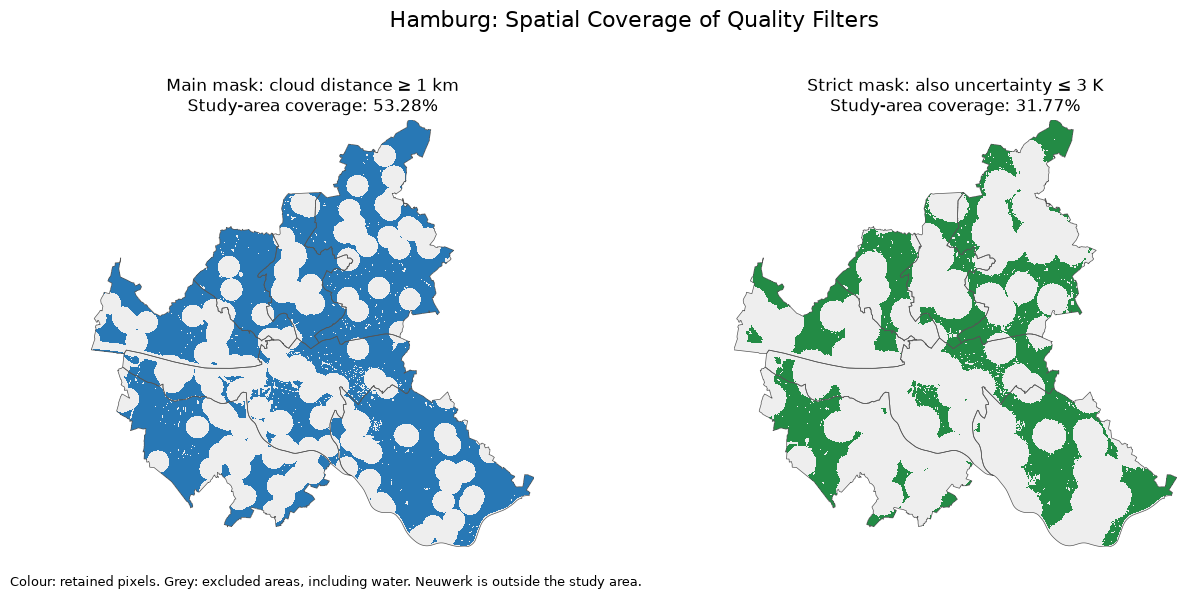

Coverage map saved to: C:\Users\PC\Documents\hamburg-green-space\outputs\landsat_quality_coverage.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rasterio.plot import plotting_extent

extent = plotting_extent(qa, crop_transform)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

scenarios = [
    ("Main mask: cloud distance ≥ 1 km", main_mask, "#2878B5"),
    ("Strict mask: also uncertainty ≤ 3 K", strict_mask, "#238B45"),
]

for ax, (title, selected, colour) in zip(axes, scenarios):

    # Background: excluded areas.
    study_districts.plot(
        ax=ax,
        facecolor="#EEEEEE",
        edgecolor="none",
        zorder=1
    )

    # Display retained pixels above the background.
    visible = np.ma.masked_where(
        ~selected,
        np.ones(qa.shape, dtype="uint8")
    )

    ax.imshow(
        visible,
        extent=extent,
        origin="upper",
        cmap=ListedColormap([colour]),
        vmin=0,
        vmax=1,
        interpolation="nearest",
        zorder=2
    )

    # Draw district boundaries on top.
    study_districts.boundary.plot(
        ax=ax,
        color="#555555",
        linewidth=0.5,
        zorder=3
    )

    coverage_pct = 100 * selected.sum() / inside.sum()

    ax.set_title(
        f"{title}\nStudy-area coverage: {coverage_pct:.2f}%",
        fontsize=12
    )
    ax.set_aspect("equal")
    ax.set_axis_off()

fig.suptitle(
    "Hamburg: Spatial Coverage of Quality Filters",
    fontsize=16
)

fig.text(
    0.02,
    0.02,
    "Colour: retained pixels. Grey: excluded areas, including water. "
    "Neuwerk is outside the study area.",
    fontsize=9
)

fig.tight_layout(rect=[0, 0.06, 1, 0.94])

OUTPUTS.mkdir(parents=True, exist_ok=True)
output_path = OUTPUTS / "landsat_quality_coverage.png"

fig.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
print("Coverage map saved to:", output_path)

In [14]:
JUNE_ID = "LC08_L2SP_195023_20260625_20260707_02_T1"
JUNE_DIR = ROOT / "data_raw" / "landsat" / JUNE_ID

june_files = {
    suffix: JUNE_DIR / f"{JUNE_ID}_{suffix}"
    for suffix in required
}

missing = []

for suffix, path in june_files.items():
    ready = path.is_file() and path.stat().st_size > 0
    print(f"{'OK' if ready else 'MISSING OR EMPTY'} — {suffix}")
    if not ready:
        missing.append(suffix)

if missing:
    raise FileNotFoundError(f"Incomplete June download: {missing}")

# Check alignment within the June scene.
with rasterio.open(june_files["SR_B4.TIF"]) as src:
    june_grid = (src.crs, src.transform, src.width, src.height)
    june_crs = src.crs
    june_bounds = box(*src.bounds)

    print("June CRS:", src.crs)
    print("June pixel size:", src.res)

for suffix, path in june_files.items():
    if suffix.endswith(".TIF"):
        with rasterio.open(path) as src:
            grid = (src.crs, src.transform, src.width, src.height)
            if grid != june_grid:
                raise ValueError(f"June grid mismatch: {suffix}")

print("All June bands share the same grid: True")

# Use the same study area as the August analysis.
june_study = study_districts.to_crs(june_crs)

covered = june_study.geometry.apply(june_bounds.covers).all()
print("Existing study area inside June raster bounds:", bool(covered))

OK — SR_B4.TIF
OK — SR_B5.TIF
OK — ST_B10.TIF
OK — QA_PIXEL.TIF
OK — QA_RADSAT.TIF
OK — SR_QA_AEROSOL.TIF
OK — ST_QA.TIF
OK — ST_CDIST.TIF
OK — MTL.txt
June CRS: EPSG:32632
June pixel size: (30.0, 30.0)
All June bands share the same grid: True
Existing study area inside June raster bounds: True


In [15]:
# Create a separate crop and mask for June.
june_shapes = [
    geom.__geo_interface__
    for geom in june_study.geometry
]

with rasterio.open(june_files["QA_PIXEL.TIF"]) as src:
    june_crop, june_transform = mask(
        src, june_shapes, crop=True, filled=False
    )

june_qa = june_crop.data[0]

june_inside = geometry_mask(
    june_shapes,
    out_shape=june_qa.shape,
    transform=june_transform,
    invert=True
)

def read_june(suffix):
    with rasterio.open(june_files[suffix]) as src:
        cropped, transform = mask(
            src, june_shapes, crop=True, filled=False
        )
        if (
            transform != june_transform
            or cropped.shape[1:] != june_qa.shape
        ):
            raise ValueError(f"June grid mismatch: {suffix}")

        return cropped[0].astype("float32").filled(np.nan)

# Apply the same cloud, shadow, snow and water exclusions.
june_fill = (june_qa & 1) != 0
june_bad_weather = (
    june_qa & sum(1 << b for b in (1, 2, 3, 4, 5))
) != 0
june_water = (june_qa & (1 << 7)) != 0

june_available = (
    june_inside
    & ~june_fill
    & ~np.ma.getmaskarray(june_crop)[0]
)

june_clear_land = (
    june_available & ~june_bad_weather & ~june_water
)

# Read reflectance, temperature and quality bands.
june_red_dn = read_june("SR_B4.TIF")
june_nir_dn = read_june("SR_B5.TIF")
june_temp_dn = read_june("ST_B10.TIF")
june_radsat = read_june("QA_RADSAT.TIF")
june_aerosol_raw = read_june("SR_QA_AEROSOL.TIF")

june_red = june_red_dn * 0.0000275 - 0.2
june_nir = june_nir_dn * 0.0000275 - 0.2
june_lst = june_temp_dn * 0.00341802 + 149.0 - 273.15

june_aerosol = np.nan_to_num(
    june_aerosol_raw, nan=0
).astype("uint16")

june_high_aerosol = ((june_aerosol >> 6) & 3) == 3

june_reflectance_ok = (
    june_clear_land
    & (june_radsat == 0)
    & np.isfinite(june_aerosol_raw)
    & ~june_high_aerosol
    & (june_red_dn > 0)
    & (june_nir_dn > 0)
    & (june_red >= 0) & (june_red <= 1)
    & (june_nir >= 0) & (june_nir <= 1)
    & ((june_nir + june_red) > 0)
)

june_ndvi = np.full(june_red.shape, np.nan, dtype="float32")
np.divide(
    june_nir - june_red,
    june_nir + june_red,
    out=june_ndvi,
    where=june_reflectance_ok
)

june_temperature_ok = (
    june_clear_land
    & (june_radsat == 0)
    & (june_temp_dn > 0)
    & np.isfinite(june_lst)
)
june_lst[~june_temperature_ok] = np.nan

june_paired = np.isfinite(june_ndvi) & np.isfinite(june_lst)

june_uncertainty = read_june("ST_QA.TIF") * 0.01
june_cloud_distance = read_june("ST_CDIST.TIF") * 0.01

june_quality = (
    june_paired
    & np.isfinite(june_uncertainty)
    & np.isfinite(june_cloud_distance)
    & (june_uncertainty >= 0)
    & (june_cloud_distance >= 0)
)

june_main = june_quality & (june_cloud_distance >= 1.0)
june_strict = june_main & (june_uncertainty <= 3.0)

total_june = june_inside.sum()

if total_june == 0 or not june_quality.any():
    raise ValueError("No usable June pixels; inspect the input data.")

print(f"Available data: {100 * june_available.sum() / total_june:.2f}%")
print(f"Paired coverage: {100 * june_paired.sum() / total_june:.2f}%")
print(f"Main coverage: {100 * june_main.sum() / total_june:.2f}%")
print(f"Strict coverage: {100 * june_strict.sum() / total_june:.2f}%")
print(
    "Median temperature uncertainty: "
    f"{np.median(june_uncertainty[june_quality]):.2f} K"
)

Available data: 100.00%
Paired coverage: 92.80%
Main coverage: 78.75%
Strict coverage: 64.27%
Median temperature uncertainty: 2.55 K


In [16]:
rows = []

for _, district in june_study.iterrows():
    district_pixels = geometry_mask(
        [district.geometry.__geo_interface__],
        out_shape=june_qa.shape,
        transform=june_transform,
        invert=True
    )

    total = district_pixels.sum()
    if total == 0:
        raise ValueError(f"No pixels for {district['bezirk_name']}")

    rows.append({
        "district": district["bezirk_name"],
        "main_coverage_pct": (
            100 * (district_pixels & june_main).sum() / total
        ),
        "strict_coverage_pct": (
            100 * (district_pixels & june_strict).sum() / total
        )
    })

june_district_coverage = pd.DataFrame(rows)
display(june_district_coverage.round(2))

,district,main_coverage_pct,strict_coverage_pct
0,Hamburg-Mitte,47.77,27.66
1,Altona,70.73,48.64
2,Eimsbüttel,90.16,78.20
3,Hamburg-Nord,91.67,82.72
4,Wandsbek,97.77,95.80
5,Bergedorf,86.17,74.89
6,Harburg,74.99,49.04


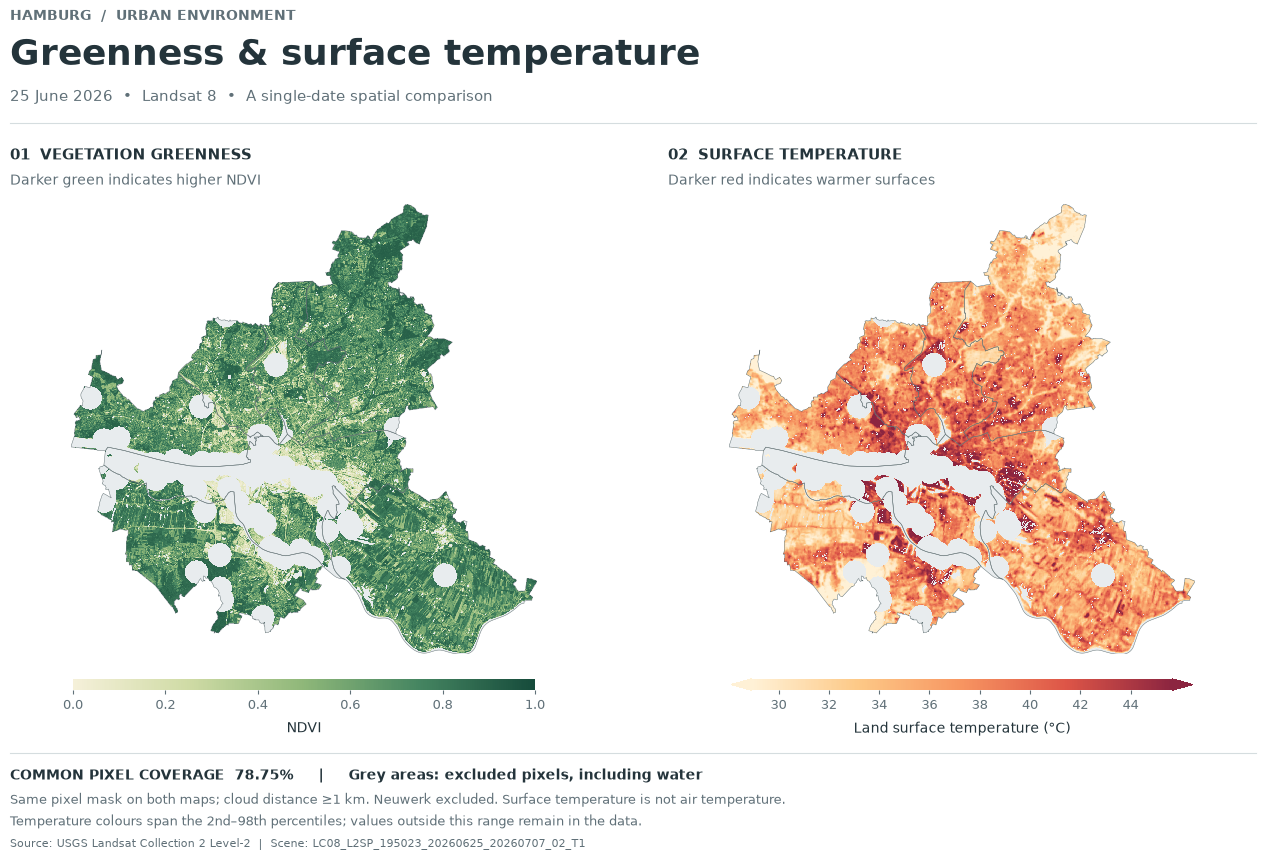

Styled map saved as PNG and PDF.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from rasterio.plot import plotting_extent

# Presentation colours.
GREEN = LinearSegmentedColormap.from_list(
    "vegetation",
    ["#F5F0D9", "#CFDBA5", "#8EB779", "#458561", "#164B3B"]
)
HEAT = LinearSegmentedColormap.from_list(
    "surface_heat",
    ["#FFF1D6", "#FDC987", "#F79561", "#DD5547", "#8C2540"]
)

TEXT = "#24343B"
MUTED = "#607078"
NO_DATA = "#E8ECEE"

extent = plotting_extent(june_qa, june_transform)
coverage = 100 * june_main.sum() / june_inside.sum()

ndvi_view = np.ma.masked_where(~june_main, june_ndvi)
lst_view = np.ma.masked_where(~june_main, june_lst)

temp_low, temp_high = np.percentile(
    june_lst[june_main], [2, 98]
)

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": MUTED,
    "ytick.color": MUTED
}):
    fig = plt.figure(figsize=(14, 9), facecolor="white")

    # Header.
    fig.text(
        0.055, 0.95,
        "HAMBURG  /  URBAN ENVIRONMENT",
        fontsize=10, fontweight="bold", color=MUTED
    )
    fig.text(
        0.055, 0.90,
        "Greenness & surface temperature",
        fontsize=26, fontweight="bold"
    )
    fig.text(
        0.055, 0.86,
        "25 June 2026  •  Landsat 8  •  A single-date spatial comparison",
        fontsize=11, color=MUTED
    )

    fig.add_artist(plt.Line2D(
        [0.055, 0.945], [0.835, 0.835],
        transform=fig.transFigure,
        color="#D5DDDF", linewidth=0.8
    ))

    panels = [
        {
            "left": 0.055,
            "title": "01  VEGETATION GREENNESS",
            "subtitle": "Darker green indicates higher NDVI",
            "values": ndvi_view,
            "cmap": GREEN,
            "low": 0,
            "high": 1,
            "label": "NDVI",
            "extend": "neither"
        },
        {
            "left": 0.525,
            "title": "02  SURFACE TEMPERATURE",
            "subtitle": "Darker red indicates warmer surfaces",
            "values": lst_view,
            "cmap": HEAT,
            "low": temp_low,
            "high": temp_high,
            "label": "Land surface temperature (°C)",
            "extend": "both"
        }
    ]

    for panel in panels:
        left = panel["left"]

        fig.text(
            left, 0.795, panel["title"],
            fontsize=11, fontweight="bold"
        )
        fig.text(
            left, 0.767, panel["subtitle"],
            fontsize=10, color=MUTED
        )

        ax = fig.add_axes([left, 0.245, 0.42, 0.50])

        june_study.plot(
            ax=ax,
            facecolor=NO_DATA,
            edgecolor="none",
            zorder=1
        )

        raster = ax.imshow(
            panel["values"],
            extent=extent,
            origin="upper",
            cmap=panel["cmap"],
            vmin=panel["low"],
            vmax=panel["high"],
            interpolation="nearest",
            zorder=2
        )

        june_study.boundary.plot(
            ax=ax,
            color="#657477",
            linewidth=0.35,
            zorder=3
        )

        ax.set_aspect("equal")
        ax.set_axis_off()

        cax = fig.add_axes([left + 0.045, 0.205, 0.33, 0.013])
        cb = fig.colorbar(
            raster,
            cax=cax,
            orientation="horizontal",
            extend=panel["extend"]
        )
        cb.outline.set_visible(False)
        cb.ax.tick_params(labelsize=9, length=3)
        cb.set_label(panel["label"], fontsize=10, labelpad=7)

    # Shared method and source notes.
    fig.add_artist(plt.Line2D(
        [0.055, 0.945], [0.135, 0.135],
        transform=fig.transFigure,
        color="#D5DDDF", linewidth=0.8
    ))

    fig.text(
        0.055, 0.106,
        f"COMMON PIXEL COVERAGE  {coverage:.2f}%"
        "     |     Grey areas: excluded pixels, including water",
        fontsize=10, fontweight="bold"
    )
    fig.text(
        0.055, 0.079,
        "Same pixel mask on both maps; cloud distance ≥1 km. "
        "Neuwerk excluded. Surface temperature is not air temperature.",
        fontsize=9, color=MUTED
    )
    fig.text(
        0.055, 0.055,
        "Temperature colours span the 2nd–98th percentiles; "
        "values outside this range remain in the data.",
        fontsize=9, color=MUTED
    )
    fig.text(
        0.055, 0.031,
        "Source: USGS Landsat Collection 2 Level-2"
        "  |  Scene: LC08_L2SP_195023_20260625_20260707_02_T1",
        fontsize=8, color=MUTED
    )

    OUTPUTS.mkdir(parents=True, exist_ok=True)

    for extension in ("png", "pdf"):
        fig.savefig(
            OUTPUTS / f"hamburg_ndvi_lst_20260625_styled.{extension}",
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

    plt.show()

print("Styled map saved as PNG and PDF.")

In [18]:
import pandas as pd
import numpy as np

# Confirm the pixel dimensions before creating 300 m cells.
if not (
    np.isclose(abs(june_transform.a), 30)
    and np.isclose(abs(june_transform.e), 30)
    and np.isclose(june_transform.b, 0)
    and np.isclose(june_transform.d, 0)
):
    raise ValueError("Expected a north-up raster with 30 m pixels.")

BLOCK = 10
height, width = june_inside.shape
rows = []

for row in range(0, height, BLOCK):
    for col in range(0, width, BLOCK):
        section = (
            slice(row, min(row + BLOCK, height)),
            slice(col, min(col + BLOCK, width))
        )

        area_pixels = june_inside[section]
        valid_pixels = june_main[section] & area_pixels

        n_inside = int(area_pixels.sum())
        n_valid = int(valid_pixels.sum())

        # Require at least 80 of the full cell's 100 pixels
        # inside the study area.
        if n_inside < 80:
            continue

        valid_fraction = n_valid / n_inside

        if valid_fraction < 0.70:
            continue

        ndvi_values = june_ndvi[section][valid_pixels]
        lst_values = june_lst[section][valid_pixels]

        centre_x, centre_y = june_transform * (
            col + BLOCK / 2,
            row + BLOCK / 2
        )

        rows.append({
            "cell_id": f"r{row // BLOCK}_c{col // BLOCK}",
            "easting": centre_x,
            "northing": centre_y,
            "inside_pixels": n_inside,
            "valid_pixels": n_valid,
            "valid_fraction": valid_fraction,
            "mean_ndvi": float(ndvi_values.mean()),
            "mean_lst_c": float(lst_values.mean())
        })

june_grid = pd.DataFrame(rows)

if june_grid.empty:
    raise ValueError("No grid cells passed the coverage criteria.")

print("Retained 300 m cells:", len(june_grid))
print(
    "Median valid coverage within study-area portion of cells: "
    f"{100 * june_grid['valid_fraction'].median():.1f}%"
)

display(
    june_grid[[
        "cell_id",
        "valid_pixels",
        "mean_ndvi",
        "mean_lst_c"
    ]].head().round(3)
)

Retained 300 m cells: 6316
Median valid coverage within study-area portion of cells: 100.0%


,cell_id,valid_pixels,mean_ndvi,mean_lst_c
0,r0_c95,90,0.836,30.942
1,r1_c95,100,0.807,31.003
2,r1_c96,100,0.809,30.395
3,r2_c94,93,0.835,30.047
4,r2_c95,100,0.803,30.679


Number of 300 m cells: 6,316
Pearson r: -0.894
Spearman rho: -0.905


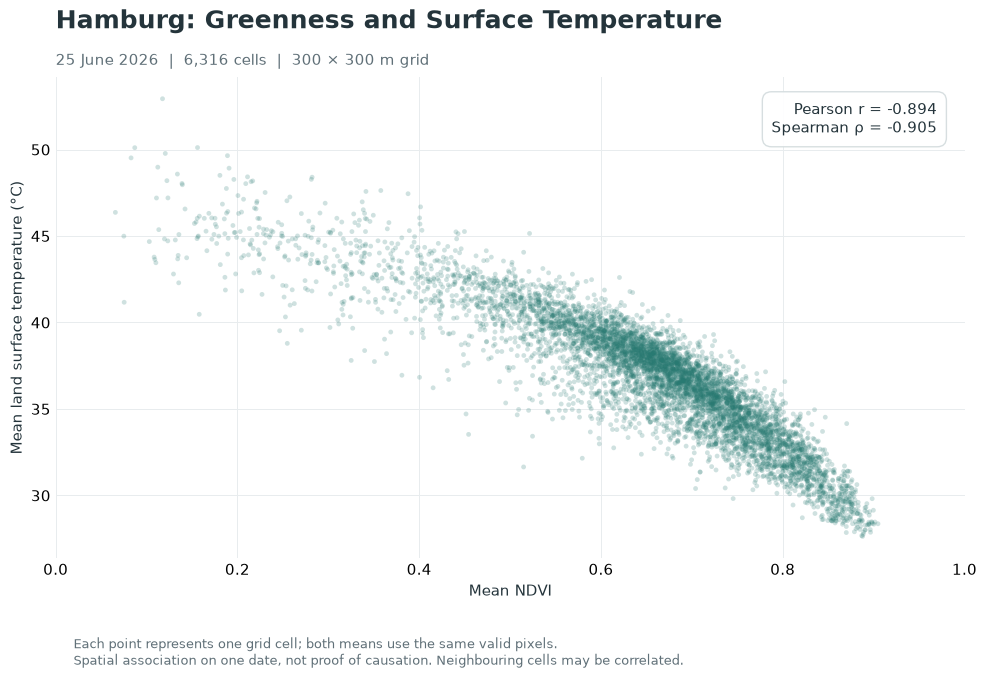

Scatter plot and grid table saved.


In [19]:
# Descriptive correlations between 300 m cell means.
x = june_grid["mean_ndvi"]
y = june_grid["mean_lst_c"]

pearson_r = x.corr(y)

# Pearson correlation of ranks gives Spearman correlation.
spearman_rho = x.rank().corr(y.rank())

print(f"Number of 300 m cells: {len(june_grid):,}")
print(f"Pearson r: {pearson_r:.3f}")
print(f"Spearman rho: {spearman_rho:.3f}")

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "text.color": "#24343B",
    "axes.labelcolor": "#24343B"
}):
    fig, ax = plt.subplots(figsize=(10, 7))

    ax.scatter(
        x, y,
        s=12,
        alpha=0.22,
        color="#287A72",
        edgecolors="none",
        rasterized=True
    )

    ax.set_title(
        "Hamburg: Greenness and Surface Temperature",
        loc="left",
        fontsize=18,
        fontweight="bold",
        pad=35
    )

    ax.text(
        0, 1.025,
        f"25 June 2026  |  {len(june_grid):,} cells  |  "
        "300 × 300 m grid",
        transform=ax.transAxes,
        fontsize=11,
        color="#607078"
    )

    ax.set_xlabel("Mean NDVI")
    ax.set_ylabel("Mean land surface temperature (°C)")
    ax.set_xlim(0, 1)

    ax.text(
        0.97, 0.95,
        f"Pearson r = {pearson_r:.3f}\n"
        f"Spearman ρ = {spearman_rho:.3f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        bbox={
            "boxstyle": "round,pad=0.6",
            "facecolor": "white",
            "edgecolor": "#D5DDDF",
            "alpha": 0.95
        }
    )

    ax.set_axisbelow(True)
    ax.grid(color="#E8ECEE", linewidth=0.7)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(length=0)

    fig.text(
        0.08, 0.04,
        "Each point represents one grid cell; both means use the same valid pixels.\n"
        "Spatial association on one date, not proof of causation. "
        "Neighbouring cells may be correlated.",
        fontsize=9,
        color="#607078"
    )

    fig.tight_layout(rect=[0, 0.11, 1, 1])

    for extension in ("png", "pdf"):
        fig.savefig(
            OUTPUTS / f"hamburg_ndvi_lst_scatter_20260625.{extension}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

june_grid.to_csv(
    OUTPUTS / "hamburg_ndvi_lst_grid_300m_20260625.csv",
    index=False
)

print("Scatter plot and grid table saved.")

## Initial result: greenness and surface temperature

Across 6,316 retained 300 × 300 m grid cells, mean NDVI
was strongly negatively associated with mean land surface
temperature on 25 June 2026.

Pearson's r was −0.894 and Spearman's ρ was −0.905.
Both variables were averaged over the same valid pixels
within each cell.

This is a spatial association for one acquisition date,
not evidence of causation. Coverage filters, land-cover
differences and spatial dependence between neighbouring
cells may influence the result.


In [20]:
# Repeat the 300 m analysis using the stricter quality mask.
# Keep the same grid origin and coverage requirements.
strict_rows = []
height, width = june_inside.shape
block_size = 10

for row in range(0, height, block_size):
    for col in range(0, width, block_size):
        section = (
            slice(row, min(row + block_size, height)),
            slice(col, min(col + block_size, width))
        )

        area_pixels = june_inside[section]
        valid_pixels = june_strict[section] & area_pixels

        n_inside = int(area_pixels.sum())
        n_valid = int(valid_pixels.sum())

        if n_inside < 80 or n_valid / n_inside < 0.70:
            continue

        strict_rows.append({
            "cell_id": f"r{row // block_size}_c{col // block_size}",
            "mean_ndvi": float(
                june_ndvi[section][valid_pixels].mean()
            ),
            "mean_lst_c": float(
                june_lst[section][valid_pixels].mean()
            )
        })

june_grid_strict = pd.DataFrame(strict_rows)

if len(june_grid_strict) < 3:
    raise ValueError("Too few cells passed the strict criteria.")

# Compare both filters on the same set of retained cells.
common_ids = set(june_grid_strict["cell_id"])
main_common = june_grid[
    june_grid["cell_id"].isin(common_ids)
].copy()

def summarise_correlation(label, frame):
    x = frame["mean_ndvi"]
    y = frame["mean_lst_c"]

    return {
        "analysis": label,
        "cells": len(frame),
        "pearson_r": x.corr(y),
        "spearman_rho": x.rank().corr(y.rank())
    }

sensitivity = pd.DataFrame([
    summarise_correlation("Main: all retained cells", june_grid),
    summarise_correlation("Main: common cells only", main_common),
    summarise_correlation("Strict: common cells", june_grid_strict)
])

display(sensitivity.round(3))

sensitivity.to_csv(
    OUTPUTS / "ndvi_lst_quality_sensitivity_20260625.csv",
    index=False
)

,analysis,cells,pearson_r,spearman_rho
0,Main: all retained cells,6316,-0.894,-0.905
1,Main: common cells only,5147,-0.899,-0.898
2,Strict: common cells,5147,-0.898,-0.897


## Sensitivity to temperature-quality filtering

The negative NDVI–surface-temperature association remained
similar under the stricter temperature-uncertainty filter.

Among 5,147 cells retained under both scenarios, Pearson's r
changed from −0.899 to −0.898, and Spearman's ρ changed from
−0.898 to −0.897.

This indicates low sensitivity to this particular filter
within the common set of cells. It does not resolve spatial
dependence, single-date limitations or establish causality.

In [21]:
import sqlite3

park_path = ROOT / "data_processed" / "hamburg_parks_fixed.gpkg"

if not park_path.is_file():
    raise FileNotFoundError(park_path)

with sqlite3.connect(
    park_path.as_uri() + "?mode=ro", uri=True
) as connection:
    park_layers = connection.execute("""
        SELECT table_name, srs_id
        FROM gpkg_contents
        WHERE data_type = 'features'
    """).fetchall()

print("Park layers:", park_layers)

Park layers: [('hamburg_parks_fixed', 25832)]


In [22]:
import geopandas as gpd

# Load parks and align their CRS with the June analysis.
parks = gpd.read_file(
    park_path,
    layer="hamburg_parks_fixed"
).to_crs(june_crs)

if (
    parks.empty
    or parks.geometry.isna().any()
    or parks.geometry.is_empty.any()
    or not parks.geometry.is_valid.all()
):
    raise ValueError("Park geometries need checking.")

# Recreate grid-cell centre points from their saved coordinates.
cell_centres = gpd.GeoDataFrame(
    june_grid.copy(),
    geometry=gpd.points_from_xy(
        june_grid["easting"],
        june_grid["northing"]
    ),
    crs=june_crs
)

# A point inside a park receives distance 0.
nearest = gpd.sjoin_nearest(
    cell_centres,
    parks[["geometry"]],
    how="left",
    distance_col="distance_to_park_m"
)

# Equally near parks can produce duplicate rows.
distances = nearest.groupby("cell_id")["distance_to_park_m"].min()

priority_cells = cell_centres.copy()
priority_cells["distance_to_park_m"] = (
    priority_cells["cell_id"].map(distances)
)

if priority_cells["distance_to_park_m"].isna().any():
    raise ValueError("Some cells have no park-distance result.")

print("Cells:", len(priority_cells))
print(
    "Median distance to a mapped park: "
    f"{priority_cells['distance_to_park_m'].median():.1f} m"
)
print(
    "Cell centres more than 500 m from mapped parks:",
    int((priority_cells["distance_to_park_m"] > 500).sum())
)

display(
    priority_cells[[
        "cell_id",
        "mean_ndvi",
        "mean_lst_c",
        "distance_to_park_m"
    ]].head().round(3)
)

Cells: 6316
Median distance to a mapped park: 560.1 m
Cell centres more than 500 m from mapped parks: 3383


,cell_id,mean_ndvi,mean_lst_c,distance_to_park_m
0,r0_c95,0.836,30.942,4939.873
1,r1_c95,0.807,31.003,4650.242
2,r1_c96,0.809,30.395,4739.649
3,r2_c94,0.835,30.047,4285.749
4,r2_c95,0.803,30.679,4362.014


In [23]:
# Percentile scores within the retained analysis cells.
# Scores indicate relative position, not absolute need.
priority_cells["park_score"] = (
    priority_cells["distance_to_park_m"]
    .rank(method="average", pct=True) * 100
)

priority_cells["low_green_score"] = (
    (-priority_cells["mean_ndvi"])
    .rank(method="average", pct=True) * 100
)

priority_cells["heat_score"] = (
    priority_cells["mean_lst_c"]
    .rank(method="average", pct=True) * 100
)

score_columns = ["park_score", "low_green_score", "heat_score"]

priority_cells["priority_score"] = (
    priority_cells[score_columns].mean(axis=1)
)

# Alternative: assign half the weight to park distance.
priority_cells["priority_access_weighted"] = (
    0.50 * priority_cells["park_score"]
    + 0.25 * priority_cells["low_green_score"]
    + 0.25 * priority_cells["heat_score"]
)

# Compare equally sized top-10% shortlists.
top_n = int(np.ceil(len(priority_cells) * 0.10))

ranked_equal = priority_cells.sort_values(
    ["priority_score", "cell_id"],
    ascending=[False, True]
)

ranked_access = priority_cells.sort_values(
    ["priority_access_weighted", "cell_id"],
    ascending=[False, True]
)

top_equal = set(ranked_equal.head(top_n)["cell_id"])
top_access = set(ranked_access.head(top_n)["cell_id"])

overlap = len(top_equal & top_access)

print(
    "Equal-weight score range: "
    f"{priority_cells['priority_score'].min():.1f}–"
    f"{priority_cells['priority_score'].max():.1f}"
)
print("Cells in each top-10% shortlist:", top_n)
print(
    "Shortlist overlap under alternative weights: "
    f"{overlap}/{top_n} ({100 * overlap / top_n:.1f}%)"
)

display(
    ranked_equal[[
        "cell_id",
        "distance_to_park_m",
        "mean_ndvi",
        "mean_lst_c",
        "priority_score"
    ]].head(10).round(2)
)

Equal-weight score range: 0.9–97.4
Cells in each top-10% shortlist: 632
Shortlist overlap under alternative weights: 483/632 (76.4%)


,cell_id,distance_to_park_m,mean_ndvi,mean_lst_c,priority_score
4192,r89_c43,3020.20,0.11,47.20,97.37
4124,r88_c43,2981.54,0.12,48.20,97.33
4056,r87_c43,2972.79,0.12,47.20,97.23
3852,r84_c43,3124.31,0.18,45.53,97.07
4055,r87_c42,3272.73,0.17,44.81,97.02
4191,r89_c42,3315.85,0.25,45.65,97.00
4123,r88_c42,3280.68,0.28,44.90,96.47
4125,r88_c44,2682.59,0.11,45.37,96.25
4193,r89_c44,2725.50,0.14,45.09,96.16
4057,r87_c44,2672.87,0.12,44.83,95.96


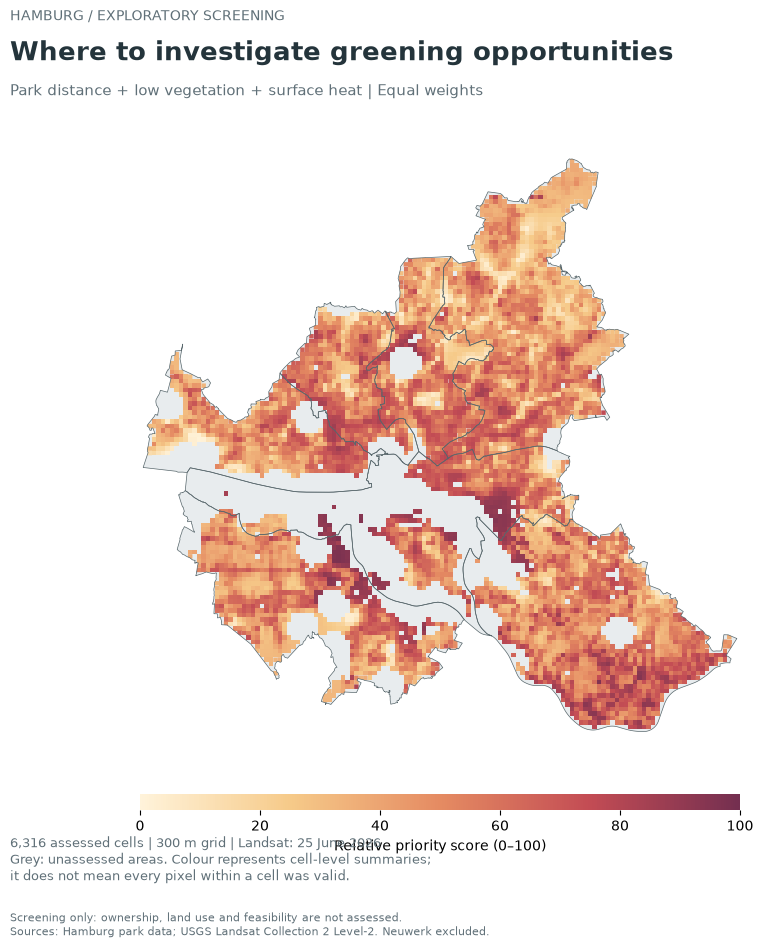

Priority map saved as PNG and PDF.
Priority grid saved in data_processed.


In [24]:
from shapely.geometry import box
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from shapely.ops import unary_union

# Reconstruct the full 300 m grid cells.
priority_grid = priority_cells.copy()

priority_grid.geometry = [
    box(x - 150, y - 150, x + 150, y + 150)
    for x, y in zip(
        priority_cells["easting"],
        priority_cells["northing"]
    )
]

# Clip display polygons to the study boundary.
study_boundary = unary_union(june_study.geometry)
priority_grid.geometry = (
    priority_grid.geometry.intersection(study_boundary)
)

priority_grid["top10_equal"] = (
    priority_grid["cell_id"].isin(top_equal)
)
priority_grid["top10_both"] = (
    priority_grid["cell_id"].isin(top_equal & top_access)
)

palette = LinearSegmentedColormap.from_list(
    "greening_priority",
    ["#FFF3DA", "#F6CA89", "#E58B62", "#C34C54", "#742F50"]
)

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 10
}):
    fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")
    fig.subplots_adjust(left=0.06, right=0.94, top=0.84, bottom=0.21)

    fig.text(
        0.07, 0.95,
        "HAMBURG / EXPLORATORY SCREENING",
        fontsize=10, color="#607078"
    )
    fig.text(
        0.07, 0.91,
        "Where to investigate greening opportunities",
        fontsize=19, fontweight="bold", color="#24343B"
    )
    fig.text(
        0.07, 0.875,
        "Park distance + low vegetation + surface heat | Equal weights",
        fontsize=11, color="#607078"
    )

    june_study.plot(
        ax=ax,
        facecolor="#E8ECEE",
        edgecolor="none",
        zorder=1
    )

    priority_grid.plot(
        ax=ax,
        column="priority_score",
        cmap=palette,
        vmin=0,
        vmax=100,
        edgecolor="none",
        zorder=2
    )

    june_study.boundary.plot(
        ax=ax,
        color="#58676C",
        linewidth=0.5,
        zorder=3
    )

    ax.set_aspect("equal")
    ax.set_axis_off()

    colourbar_ax = fig.add_axes([0.20, 0.16, 0.60, 0.016])
    colourbar = fig.colorbar(
        ScalarMappable(norm=Normalize(0, 100), cmap=palette),
        cax=colourbar_ax,
        orientation="horizontal"
    )
    colourbar.set_label("Relative priority score (0–100)")
    colourbar.outline.set_visible(False)

    fig.text(
        0.07, 0.09,
        "6,316 assessed cells | 300 m grid | Landsat: 25 June 2026\n"
        "Grey: unassessed areas. Colour represents cell-level summaries;\n"
        "it does not mean every pixel within a cell was valid.",
        fontsize=9, color="#607078"
    )
    fig.text(
        0.07, 0.035,
        "Screening only: ownership, land use and feasibility are not assessed.\n"
        "Sources: Hamburg park data; USGS Landsat Collection 2 Level-2. "
        "Neuwerk excluded.",
        fontsize=8, color="#607078"
    )

    for extension in ("png", "pdf"):
        fig.savefig(
            OUTPUTS / f"hamburg_greening_priority_20260625.{extension}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

# GeoJSON preserves the cells and scores for the interactive map.
priority_grid.to_crs(epsg=4326).to_file(
    DATA / "hamburg_greening_priority_grid.geojson",
    driver="GeoJSON"
)

print("Priority map saved as PNG and PDF.")
print("Priority grid saved in data_processed.")

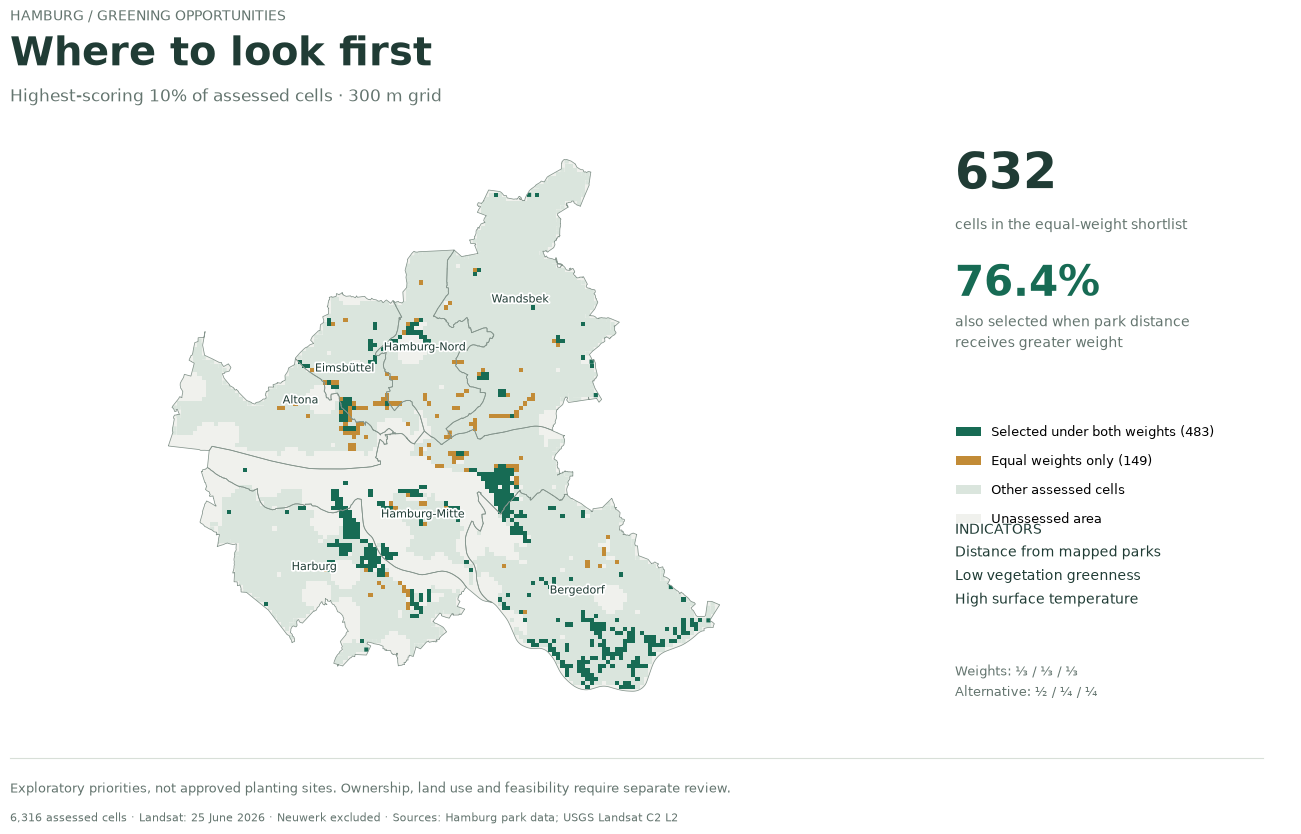

Shortlist map saved as PNG and PDF.


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch

# Preserve the scores; change only how the shortlist is displayed.
stable = priority_grid[
    priority_grid["cell_id"].isin(top_equal & top_access)
]
weight_sensitive = priority_grid[
    priority_grid["cell_id"].isin(top_equal - top_access)
]

INK = "#203C35"
MUTED = "#64756F"
GREEN = "#176B54"
GOLD = "#C28B36"
ASSESSED = "#DAE5DD"
UNASSESSED = "#F0F1ED"

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 10
}):
    fig = plt.figure(figsize=(14, 9), facecolor="white")
    ax = fig.add_axes([0.04, 0.17, 0.65, 0.65])
    notes = fig.add_axes([0.73, 0.20, 0.24, 0.57])
    notes.set_axis_off()

    fig.text(
        0.055, 0.945, "HAMBURG / GREENING OPPORTUNITIES",
        fontsize=10, color=MUTED
    )
    fig.text(
        0.055, 0.895, "Where to look first",
        fontsize=29, fontweight="bold", color=INK
    )
    fig.text(
        0.055, 0.855,
        "Highest-scoring 10% of assessed cells · 300 m grid",
        fontsize=12, color=MUTED
    )

    june_study.plot(
        ax=ax, facecolor=UNASSESSED,
        edgecolor="none", zorder=1
    )
    priority_grid.plot(
        ax=ax, color=ASSESSED,
        edgecolor="none", zorder=2
    )
    weight_sensitive.plot(
        ax=ax, color=GOLD,
        edgecolor="none", zorder=3
    )
    stable.plot(
        ax=ax, color=GREEN,
        edgecolor="none", zorder=4
    )
    june_study.boundary.plot(
        ax=ax, color="#84948C",
        linewidth=0.55, zorder=5
    )

    # District names provide geographic context.
    for _, district in june_study.iterrows():
        point = district.geometry.representative_point()
        label = ax.text(
            point.x, point.y,
            district["bezirk_name"],
            ha="center", va="center",
            fontsize=8, color=INK, zorder=6
        )
        label.set_path_effects([
            pe.withStroke(linewidth=2.5, foreground="white")
        ])

    ax.set_aspect("equal")
    ax.set_axis_off()

    notes.text(
        0, 0.98, f"{len(top_equal):,}",
        fontsize=35, fontweight="bold", color=INK
    )
    notes.text(
        0, 0.90, "cells in the equal-weight shortlist",
        fontsize=10, color=MUTED
    )

    notes.text(
        0, 0.77,
        f"{100 * len(stable) / len(top_equal):.1f}%",
        fontsize=30, fontweight="bold", color=GREEN
    )
    notes.text(
        0, 0.67,
        "also selected when park distance\nreceives greater weight",
        fontsize=10, color=MUTED, linespacing=1.5
    )

    notes.legend(
        handles=[
            Patch(facecolor=GREEN,
                  label=f"Selected under both weights ({len(stable)})"),
            Patch(facecolor=GOLD,
                  label=f"Equal weights only ({len(weight_sensitive)})"),
            Patch(facecolor=ASSESSED,
                  label="Other assessed cells"),
            Patch(facecolor=UNASSESSED,
                  label="Unassessed area")
        ],
        loc="upper left",
        bbox_to_anchor=(-0.03, 0.54),
        frameon=False,
        fontsize=9,
        labelspacing=1.2
    )

    notes.text(
        0, 0.17,
        "INDICATORS\n"
        "Distance from mapped parks\n"
        "Low vegetation greenness\n"
        "High surface temperature",
        fontsize=10, color=INK, linespacing=1.7
    )
    notes.text(
        0, -0.01,
        "Weights: ⅓ / ⅓ / ⅓\n"
        "Alternative: ½ / ¼ / ¼",
        fontsize=9, color=MUTED, linespacing=1.6
    )

    fig.add_artist(plt.Line2D(
        [0.055, 0.95], [0.125, 0.125],
        transform=fig.transFigure,
        color="#D8DFD8", linewidth=0.8
    ))
    fig.text(
        0.055, 0.087,
        "Exploratory priorities, not approved planting sites. "
        "Ownership, land use and feasibility require separate review.",
        fontsize=9, color=MUTED
    )
    fig.text(
        0.055, 0.055,
        "6,316 assessed cells · Landsat: 25 June 2026 · "
        "Neuwerk excluded · Sources: Hamburg park data; USGS Landsat C2 L2",
        fontsize=8, color=MUTED
    )

    for extension in ("png", "pdf"):
        fig.savefig(
            OUTPUTS / f"hamburg_greening_shortlist.{extension}",
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

    plt.show()

print("Shortlist map saved as PNG and PDF.")

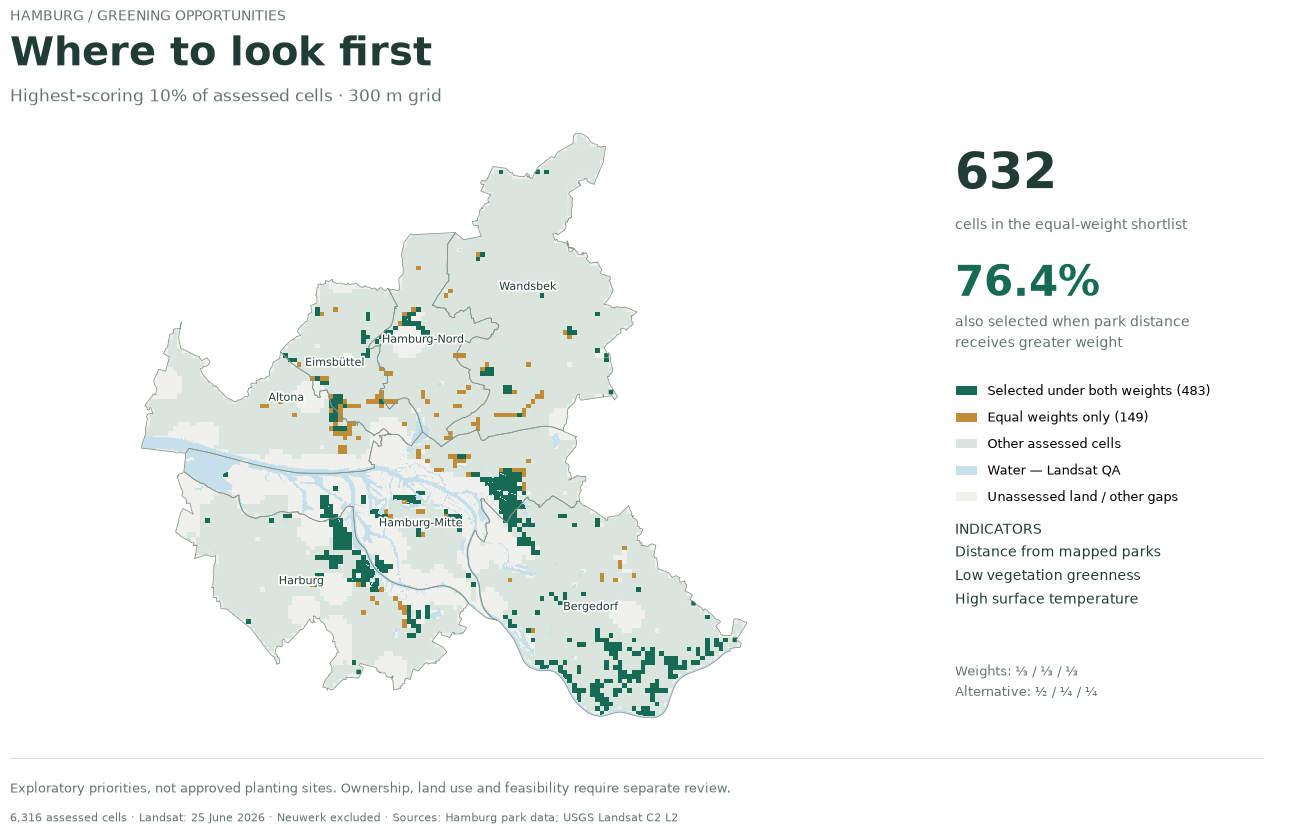

Water-aware map saved as PNG and PDF.


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from rasterio.plot import plotting_extent

# Reuse the figure created by the previous map cell.
map_ax = fig.axes[0]
notes_ax = fig.axes[1]

# Show water identified in the June Landsat quality band.
# Keep cloudy or unavailable pixels out of this display layer.
water_display = (
    june_inside
    & june_available
    & ~june_bad_weather
    & june_water
)

water_image = np.ma.masked_where(
    ~water_display,
    np.ones(june_water.shape, dtype="uint8")
)

map_ax.imshow(
    water_image,
    extent=plotting_extent(june_qa, june_transform),
    cmap=ListedColormap(["#C6E0EB"]),
    interpolation="nearest",
    origin="upper",
    zorder=4.5
)

# Replace the legend and leave more space above the indicators.
old_legend = notes_ax.get_legend()
if old_legend is not None:
    old_legend.remove()

legend_items = [
    Patch(
        facecolor="#176B54",
        label="Selected under both weights (483)"
    ),
    Patch(
        facecolor="#C28B36",
        label="Equal weights only (149)"
    ),
    Patch(
        facecolor="#DAE5DD",
        label="Other assessed cells"
    ),
    Patch(
        facecolor="#C6E0EB",
        label="Water — Landsat QA"
    ),
    Patch(
        facecolor="#F0F1ED",
        label="Unassessed land / other gaps"
    )
]

notes_ax.legend(
    handles=legend_items,
    loc="upper left",
    bbox_to_anchor=(-0.03, 0.62),
    frameon=False,
    fontsize=9,
    labelspacing=1.0,
    handlelength=1.7
)

# Save a separate version for comparison.
OUTPUTS.mkdir(parents=True, exist_ok=True)

fig.savefig(
    OUTPUTS / "hamburg_greening_shortlist_water.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    OUTPUTS / "hamburg_greening_shortlist_water.pdf",
    bbox_inches="tight",
    facecolor="white"
)

display(fig)
print("Water-aware map saved as PNG and PDF.")

In [27]:
# Save the priority grid and its indicators for the interactive map.
export_grid = priority_grid.copy()

export_grid["top10_equal"] = export_grid["cell_id"].isin(top_equal)
export_grid["top10_both"] = export_grid["cell_id"].isin(
    top_equal & top_access
)

export_grid = export_grid.to_crs("EPSG:4326")

geojson_path = DATA / "hamburg_greening_priority_grid.geojson"
export_grid.to_file(
    geojson_path,
    driver="GeoJSON",
    index=False
)

# Save a non-spatial table for inspection and reuse.
csv_path = OUTPUTS / "hamburg_greening_priority_scores.csv"
export_grid.drop(columns="geometry").to_csv(
    csv_path,
    index=False
)

print(f"Saved cells: {len(export_grid):,}")
print(f"Equal-weight shortlist: {export_grid['top10_equal'].sum():,}")
print(f"Selected under both weights: {export_grid['top10_both'].sum():,}")
print("GeoJSON:", geojson_path)
print("CSV:", csv_path)

Saved cells: 6,316
Equal-weight shortlist: 632
Selected under both weights: 483
GeoJSON: C:\Users\PC\Documents\hamburg-green-space\data_processed\hamburg_greening_priority_grid.geojson
CSV: C:\Users\PC\Documents\hamburg-green-space\outputs\hamburg_greening_priority_scores.csv


In [28]:
%pip install folium

  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached xyzservices-2026.9.1-py3-none-any.whl.metadata (4.1 kB)
  Using cached idna-3.20-py3-none-any.whl.metadata (7.2 kB)
  Using cached urllib3-2.8.0-py3-none-any.whl.metadata (7.4 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached xyzservices-2026.9.1-py3-none-any.whl (98 kB)
Using cached idna-3.20-py3-none-any.whl (69 kB)
Using cached urllib3-2.8.0-py3-none-any.whl (135 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import folium

print("Folium is ready:", folium.__version__)

Folium is ready: 0.20.0


In [33]:
from pathlib import Path
import json

import geopandas as gpd
import folium
from branca.element import Element
from shapely.geometry import box
from IPython.display import display

# --------------------------------------------------
# 1. Locate the project and load saved results.
# --------------------------------------------------
current = Path.cwd().resolve()

project_root = next(
    (
        folder
        for folder in [current, *current.parents]
        if (folder / "data_processed").is_dir()
        and (folder / "notebooks").is_dir()
    ),
    None
)

if project_root is None:
    raise FileNotFoundError("Project folder not found.")

data_folder = project_root / "data_processed"
output_folder = project_root / "outputs"
output_folder.mkdir(parents=True, exist_ok=True)

grid = gpd.read_file(
    data_folder / "hamburg_greening_priority_grid.geojson"
).to_crs(4326)

districts_map = gpd.read_file(
    data_folder / "hamburg_districts.gpkg"
).to_crs(4326)

required = [
    "cell_id",
    "distance_to_park_m",
    "mean_ndvi",
    "mean_lst_c",
    "priority_score",
    "top10_equal",
    "top10_both",
]

missing = set(required) - set(grid.columns)

if missing:
    raise ValueError(f"Missing columns: {sorted(missing)}")

for column in ["top10_equal", "top10_both"]:
    grid[column] = (
        grid[column]
        .astype(str)
        .str.lower()
        .isin(["true", "1", "1.0"])
    )

# Keep district components intersecting the analysis extent.
# This removes remote island components from the map view.
analysis_extent = box(*grid.total_bounds)

districts_map = districts_map.explode(index_parts=False)
districts_map = districts_map[
    districts_map.geometry.notna()
    & ~districts_map.geometry.is_empty
].copy()

districts_map = districts_map[
    districts_map.intersects(analysis_extent)
].copy()

if districts_map.empty:
    raise ValueError("No district geometry overlaps the analysis.")

# Simplify the contextual boundaries in metres.
districts_map = districts_map.to_crs(25832)
districts_map["geometry"] = districts_map.geometry.simplify(
    15,
    preserve_topology=True
)
districts_map = districts_map.to_crs(4326)

# --------------------------------------------------
# 2. Prepare display fields.
# --------------------------------------------------
for column, decimals in [
    ("distance_to_park_m", 0),
    ("mean_ndvi", 3),
    ("mean_lst_c", 1),
    ("priority_score", 1),
]:
    grid[column] = grid[column].round(decimals)

grid["selection"] = "Other assessed cell"

grid.loc[
    grid["top10_equal"], "selection"
] = "Equal-weight shortlist only"

grid.loc[
    grid["top10_both"], "selection"
] = "Selected under both weights"

stable = grid[grid["top10_both"]].copy()

sensitive = grid[
    grid["top10_equal"] & ~grid["top10_both"]
].copy()

other = grid[~grid["top10_equal"]].copy()

shortlist_count = int(grid["top10_equal"].sum())
overlap_pct = (
    100 * len(stable) / shortlist_count
    if shortlist_count else 0
)

# --------------------------------------------------
# 3. Create a map without external background tiles.
# --------------------------------------------------
interactive_map = folium.Map(
    location=[53.55, 10.0],
    zoom_start=10,
    tiles=None,
    control_scale=True,
    prefer_canvas=True,
    width="100%",
    height="100%",
)

interactive_map.get_root().header.add_child(
    Element("""
    <style>
        .leaflet-container {
            background: #F8FAF9 !important;
            font-family: Arial, sans-serif;
        }

        .leaflet-control-layers {
            border: 1px solid #DCE5DF !important;
            border-radius: 8px !important;
            box-shadow: 0 2px 10px rgba(0,0,0,0.08) !important;
            padding: 10px !important;
        }

        .leaflet-popup-content {
            font-family: Arial, sans-serif;
            font-size: 12px;
            line-height: 1.6;
        }

        .leaflet-popup-content th {
            text-align: left;
            padding-right: 12px;
        }

        .district-label {
            color: #425E52;
            font: 11px Arial, sans-serif;
            text-align: center;
            white-space: nowrap;
            text-shadow:
                -1px -1px 2px white,
                 1px  1px 2px white;
            pointer-events: none !important;
        }
    </style>
    """)
)

# Pale district polygons provide geographic context.
folium.GeoJson(
    json.loads(districts_map[["geometry"]].to_json()),
    name="District background",
    control=False,
    style_function=lambda feature: {
        "fillColor": "#EEF1EE",
        "fillOpacity": 1,
        "color": "#A6B5AC",
        "weight": 1,
    },
).add_to(interactive_map)

# --------------------------------------------------
# 4. Add selectable analysis layers.
# --------------------------------------------------
popup_fields = [
    "cell_id",
    "selection",
    "distance_to_park_m",
    "mean_ndvi",
    "mean_lst_c",
    "priority_score",
]

popup_aliases = [
    "Cell:",
    "Selection:",
    "Park distance from cell centre (m):",
    "Mean NDVI:",
    "Mean surface temperature (°C):",
    "Equal-weight priority score (0–100):",
]


def add_cells(frame, name, colour, opacity):
    if frame.empty:
        return

    layer_data = json.loads(
        frame[popup_fields + ["geometry"]].to_json()
    )

    folium.GeoJson(
        layer_data,
        name=name,
        show=True,
        smooth_factor=0,
        style_function=lambda feature: {
            "fillColor": colour,
            "color": colour,
            "weight": 0.35,
            "fillOpacity": opacity,
        },
        highlight_function=lambda feature: {
            "color": "#183B2C",
            "weight": 2,
            "fillOpacity": 0.95,
        },
        tooltip=folium.GeoJsonTooltip(
            fields=["cell_id", "priority_score"],
            aliases=["Cell:", "Priority score:"],
            sticky=False,
            localize=True,
        ),
        popup=folium.GeoJsonPopup(
            fields=popup_fields,
            aliases=popup_aliases,
            labels=True,
            localize=True,
            max_width=380,
        ),
    ).add_to(interactive_map)


add_cells(
    other,
    f"Other assessed cells ({len(other):,})",
    "#D1DFD5",
    0.8,
)

add_cells(
    sensitive,
    f"Equal-weight shortlist only ({len(sensitive):,})",
    "#C28B36",
    0.9,
)

add_cells(
    stable,
    f"Selected under both weights ({len(stable):,})",
    "#176B54",
    0.95,
)

# Draw boundaries above the cells without intercepting clicks.
folium.GeoJson(
    json.loads(districts_map[["geometry"]].to_json()),
    name="District boundaries",
    control=False,
    style_function=lambda feature: {
        "fill": False,
        "color": "#8DA397",
        "weight": 1,
        "interactive": False,
    },
).add_to(interactive_map)

# Optional district labels, using the known district-name field.
if "bezirk_name" in districts_map.columns:
    labels = folium.FeatureGroup(
        name="District names",
        show=True
    )

    label_districts = districts_map.dissolve(
        by="bezirk_name"
    ).to_crs(25832)

    label_points = (
        label_districts.geometry
        .representative_point()
        .to_crs(4326)
    )

    for name, point in label_points.items():
        folium.Marker(
            location=[point.y, point.x],
            icon=folium.DivIcon(
                html=f'<div class="district-label">{name}</div>',
                icon_size=(120, 20),
                icon_anchor=(60, 10),
            ),
            interactive=False,
        ).add_to(labels)

    labels.add_to(interactive_map)

folium.LayerControl(
    position="topright",
    collapsed=False
).add_to(interactive_map)

# --------------------------------------------------
# 5. Add a compact, collapsible information panel.
# --------------------------------------------------
info_panel = f"""
<div style="
    position: fixed;
    bottom: 40px;
    left: 15px;
    z-index: 999;
    width: 285px;
    max-width: calc(100vw - 50px);
    max-height: 65vh;
    overflow-y: auto;
    background: rgba(255,255,255,0.97);
    border: 1px solid #DCE5DF;
    border-radius: 10px;
    padding: 17px;
    box-sizing: border-box;
    box-shadow: 0 3px 14px rgba(0,0,0,0.10);
    font-family: Arial, sans-serif;
    color: #203C35;
">
    <div style="font-size: 10px; letter-spacing: 1px;">
        HAMBURG · GREENING OPPORTUNITIES
    </div>

    <div style="font-size: 23px; font-weight: bold; margin: 8px 0;">
        Where to look first
    </div>

    <div style="font-size: 12px; line-height: 1.7;">
        <b>{shortlist_count:,}</b> shortlisted cells · 300 m grid<br>
        <b>{overlap_pct:.1f}%</b> overlap under alternative weights
    </div>

    <hr style="border: 0; border-top: 1px solid #DFE7E2;">

    <div style="font-size: 12px; line-height: 1.9;">
        <span style="color:#176B54;">■</span> Selected under both weights<br>
        <span style="color:#C28B36;">■</span> Equal-weight shortlist only<br>
        <span style="color:#A8BEAE;">■</span> Other assessed cells<br>
        <span style="color:#D4D9D4;">■</span> Unassessed area, including water
    </div>

    <div style="font-size: 12px; margin-top: 10px;">
        Click a cell to explore its indicators.
    </div>

    <details style="font-size: 11px; line-height: 1.6; margin-top: 12px;">
        <summary style="cursor: pointer; font-weight: bold;">
            Method and limitations
        </summary>
        <p>
            Landsat: 25 June 2026. Neuwerk excluded from analysis.<br>
            Equal weights: ⅓ park distance, ⅓ low greenness, ⅓ heat.<br>
            Alternative: ½ park distance, ¼ low greenness, ¼ heat.
        </p>
        <p>
            Distance is measured from cell centres to mapped parks
            in a straight line. Temperature refers to land surface,
            not air temperature.
        </p>
        <p>
            Exploratory screening, not approved planting sites.
            Ownership, existing land use and feasibility require review.
            Unassessed areas are not necessarily low priority.
        </p>
        <p>
            Sources: Hamburg district and park data;
            USGS Landsat Collection 2 Level-2.
        </p>
    </details>
</div>
"""

interactive_map.get_root().html.add_child(
    Element(info_panel)
)

west, south, east, north = districts_map.total_bounds

interactive_map.fit_bounds(
    [[south, west], [north, east]],
    padding_top_left=(35, 35),
    padding_bottom_right=(35, 35),
)

# Use a new filename to avoid confusing it with the old map.
html_path = output_folder / "hamburg_greening_interactive_v2.html"
interactive_map.save(str(html_path))

print(f"Assessed cells: {len(grid):,}")
print(f"Shortlisted cells: {shortlist_count:,}")
print(f"Selected under both weights: {len(stable):,}")
print("External background tiles: disabled")
print("Saved:", html_path)

# display(interactive_map)

Assessed cells: 6,316
Shortlisted cells: 632
Selected under both weights: 483
External background tiles: disabled
Saved: C:\Users\PC\Documents\hamburg-green-space\outputs\hamburg_greening_interactive_v2.html


In [34]:
# List deliverables for the project README.
for folder_name in ["notebooks", "outputs", "docs"]:
    folder = project_root / folder_name
    print(f"\n{folder_name}/")

    if folder.exists():
        for path in sorted(folder.iterdir()):
            if path.is_file() and not path.name.startswith("."):
                print(f"  {path.name}")


notebooks/
  01_park_access_analysis.ipynb
  02_greenness_surface_temperature.ipynb

outputs/
  district_park_proximity_300m_vs_500m.pdf
  district_park_proximity_300m_vs_500m.png
  district_park_proximity_500m.pdf
  district_park_proximity_500m.png
  district_park_proximity_comparison.csv
  hamburg_greening_interactive.html
  hamburg_greening_interactive_v2.html
  hamburg_greening_priority_20260625.pdf
  hamburg_greening_priority_20260625.png
  hamburg_greening_priority_scores.csv
  hamburg_greening_shortlist.pdf
  hamburg_greening_shortlist.png
  hamburg_greening_shortlist_water.pdf
  hamburg_greening_shortlist_water.png
  hamburg_ndvi_lst_20260625.png
  hamburg_ndvi_lst_20260625_styled.pdf
  hamburg_ndvi_lst_20260625_styled.png
  hamburg_ndvi_lst_grid_300m_20260625.csv
  hamburg_ndvi_lst_scatter_20260625.pdf
  hamburg_ndvi_lst_scatter_20260625.png
  hamburg_park_proximity_500m.pdf
  landsat_quality_coverage.png
  ndvi_lst_quality_sensitivity_20260625.csv

docs/
  project_notes.txt


In [35]:
notes_path = project_root / "docs" / "project_notes.txt"

print(notes_path.read_text(encoding="utf-8-sig"))

Project: Hamburg Green Space Accessibility

Main question:
Which areas of Hamburg lie outside 300 m and 500 m
straight-line buffers around mapped public parks?

Tools:
QGIS and Python

Planned outputs:
1. Park proximity map
2. District-level comparison
3. Python notebook explaining the analysis

Limitations:
Straight-line distance does not represent walking distance.
Park boundaries do not necessarily indicate park entrances.

DAY 1 — 2026-10-01

Data sources:
1. ALKIS - Verwaltungsgrenzen Hamburg
Provider: Freie und Hansestadt Hamburg, LGV
https://suche.transparenz.hamburg.de/dataset/alkis-verwaltungsgrenzen-hamburg31

2. Digitaler Gruenplan / Kataster der oeffentlichen Gruenanlagen
Attribution: Freie und Hansestadt Hamburg,
Behoerde fuer Umwelt und Energie
https://suche.transparenz.hamburg.de/dataset/digitaler-gruenplan-kataster-der-oeffentlichen-gruenanlagen18

Download date: 2026-10-01
License for both datasets:
Datenlizenz Deutschland - Namensnennung - Version 2.0
https://www.govd